# 01 · Current status of data centers and the grid in California

Chapter 1 of *Mapping the Consumption Gap*. Answers "how much of the state's power do data centers use" and builds the grid baseline from Section 3.2 of the proposal.

All numbers come from `data/raw` through `src/ch1_baseline.py`; `scripts/run_chapter1.py` writes the tables (`data/processed/ch1_*`) and figures (`figures/fig1_*`) that this notebook displays. Every table names the manifest `source_id` it was built from.

| Step | Sources (manifest ids) |
|---|---|
| 1. Hourly demand, generation by fuel, interchange, 2019-2025 | `eia930_balance_*` (Adjusted series), cross-checked against `caiso_outlook_demand` |
| 2. Day-ahead price duration curves, negative-price hours | `caiso_dam_lmp_monthly_dlap`, `caiso_dam_lmp_monthly_hubs`, `eia_ice_wholesale_*` |
| 3. Hourly carbon intensity | `caiso_outlook_co2`, `caiso_outlook_demand`, `epa_egrid2023_rev1` |
| 4. Existing data center load, four ways | `epri_powering_intelligence_2024`, `cec_dc_methodology_memo_2026`, `kollar_grady_2025_zenodo`, `epoch_data_centers`, `svp_*`, `eia861_2024` |
| 5. Institutional context | `cec_tn268288`, `cec_tn269506`, `cec_tn261964`, `cec_tn261975`, `cec_tn268459`, `pge_*`, `cpuc_oir_rate_design_2026_04`, `ca_sb57_*`, `ca_sb886_*`, `ca_ab222_*`, `cpuc_news_streamlined_connections` |


In [1]:
import sys, json, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))
import pandas as pd, numpy as np
from IPython.display import Image, display
from src.paths import PROCESSED, FIGURES
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
def show(name): display(Image(filename=str(FIGURES / f"{name}.png")))
def table(name, **kw): return pd.read_csv(PROCESSED / f"{name}.csv", **kw)
rec = json.loads((PROCESSED / "ch1_run_record.json").read_text()); rec

{'years': [2019, 2020, 2021, 2022, 2023, 2024, 2025],
 'ciso_hours': 61368,
 'lmp_hours': 28320,
 'co2_hours': 61353,
 'retail_sales_2024_TWh': 245.717145,
 'kollar_grady_california_points': 321,
 'outputs': ['ch1_battery_summary.csv',
  'ch1_bottom_up_inputs.json',
  'ch1_ca_retail_sales_eia861.csv',
  'ch1_carbon_intensity_annual.csv',
  'ch1_carbon_intensity_diurnal.csv',
  'ch1_carbon_intensity_duration.csv',
  'ch1_ciso_annual_summary.csv',
  'ch1_dc_load_estimates.csv',
  'ch1_egrid_camx_2023.json',
  'ch1_eia930_flagged_hours.csv',
  'ch1_ice_daily_hub_prices_negative_days.csv',
  'ch1_kollar_grady_points_california_flag.csv',
  'ch1_load_duration_curves.csv',
  'ch1_negative_price_hours_by_month.csv',
  'ch1_net_load_duration_curves.csv',
  'ch1_price_by_hour_of_day.csv',
  'ch1_price_duration_curves.csv',
  'ch1_price_stats.csv',
  'ch1_run_record.json',
  'ch1_seasonal_profiles.csv',
  'ch1_svp_fact_sheets.csv',
  'ch1_top100_demand_hours.csv',
  'ch1_top100_demand_timing.csv

## 1. Grid baseline: CAISO hourly demand, net load, imports (EIA-930, 2019-2025)

EIA-930 "Adjusted" series for the CISO balancing authority. Net load = demand − utility-scale solar − wind. Imports = −net interchange. EIA-930's CISO demand includes storage charging and pumping load, whereas CAISO's Today's Outlook 'Current demand' excludes charging; in 2025 the gap between the two tracks battery charging almost one-for-one. Both are kept: `demand` (EIA definition) and `demand_ex_storage` (EIA demand minus CAISO-reported charging). Hours where EIA demand is implausibly low (below 85 percent of CAISO demand plus charging, or under 5 GW) are reporting artifacts and are nulled (listed in `ch1_eia930_flagged_hours.csv`).

In [2]:
summ = table("ch1_ciso_annual_summary", index_col=0)
cols = ["hours","energy_TWh","avg_demand_MW","peak_demand_MW","peak_demand_time","load_factor","peak_net_load_MW","peak_net_load_time","min_net_load_MW","min_net_load_ex_storage_MW","storage_charging_TWh","solar_TWh","wind_TWh","gas_TWh","net_imports_TWh","import_share_of_demand","solar_wind_share_of_demand"]
summ[cols].round(3)

,hours,energy_TWh,avg_demand_MW,peak_demand_MW,peak_demand_time,load_factor,peak_net_load_MW,peak_net_load_time,min_net_load_MW,min_net_load_ex_storage_MW,storage_charging_TWh,solar_TWh,wind_TWh,gas_TWh,net_imports_TWh,import_share_of_demand,solar_wind_share_of_demand
year,,,,,,,,,,,,,,,,,
2019,8435,215.848,24640.228,43849.0,2019-08-15 18:00:00-07:00,0.562,40536.0,2019-08-14 19:00:00-07:00,5249.0,5247.167,0.076,27.698,15.850,65.206,53.827,0.249,0.202
2020,8783,217.989,24816.572,46643.0,2020-08-18 16:00:00-07:00,0.532,44026.0,2020-09-05 19:00:00-07:00,5553.0,5537.500,0.081,28.632,14.937,73.816,59.390,0.272,0.200
2021,8760,219.186,25021.244,43615.0,2021-09-08 18:00:00-07:00,0.574,40495.0,2021-09-08 19:00:00-07:00,3021.0,2943.083,0.915,32.753,18.303,79.288,54.372,0.248,0.233
2022,8760,223.662,25532.245,51104.0,2022-09-06 18:00:00-07:00,0.500,47464.0,2022-09-06 19:00:00-07:00,1938.0,1770.750,1.702,35.828,17.384,82.796,48.672,0.218,0.238
2023,8759,218.179,24906.333,44007.0,2023-08-16 19:00:00-07:00,0.566,41764.0,2023-08-15 20:00:00-07:00,1658.0,922.417,4.450,37.168,16.404,87.793,28.486,0.131,0.246
2024,8757,224.052,25506.882,47571.0,2024-09-05 19:00:00-07:00,0.536,42403.0,2024-09-05 21:00:00-07:00,253.0,-2153.750,9.451,44.743,20.046,85.357,23.432,0.105,0.289
2025,8743,224.075,25579.368,43860.0,2025-08-21 20:00:00-07:00,0.583,39787.0,2025-08-21 21:00:00-07:00,-3255.0,-4960.083,14.214,49.650,19.814,79.013,35.878,0.160,0.310


In [3]:
table("ch1_eia930_flagged_hours", index_col=0)

,demand,solar,wind,net_load,caiso_demand
hour_ending_local,,,,,
2019-02-05 11:00:00-08:00,18400.0,6297.0,2753.0,9350.0,24543.166667
2019-02-05 14:00:00-08:00,17037.0,5228.0,2355.0,9454.0,23283.416667
2019-02-05 18:00:00-08:00,23019.0,-34.0,2034.0,21019.0,27119.500000
2019-02-05 19:00:00-08:00,23943.0,-34.0,2766.0,21211.0,29028.166667
2019-02-05 20:00:00-08:00,23945.0,-34.0,2350.0,21629.0,28898.250000
...,...,...,...,...,...
2025-11-01 13:00:00-07:00,16016.0,15958.0,746.0,-688.0,22528.083333
2025-11-01 14:00:00-07:00,16391.0,15798.0,748.0,-155.0,23149.333333
2025-11-01 15:00:00-07:00,17834.0,15563.0,728.0,1543.0,24301.666667


**Reading.** CAISO annual demand has been flat at roughly 214-224 TWh since 2019 while utility-scale solar and wind rose from a fifth to nearly a third of demand and net imports fell from a quarter of demand to a tenth (2024). The hourly peak record remains September 6, 2022 (51.1 GW).

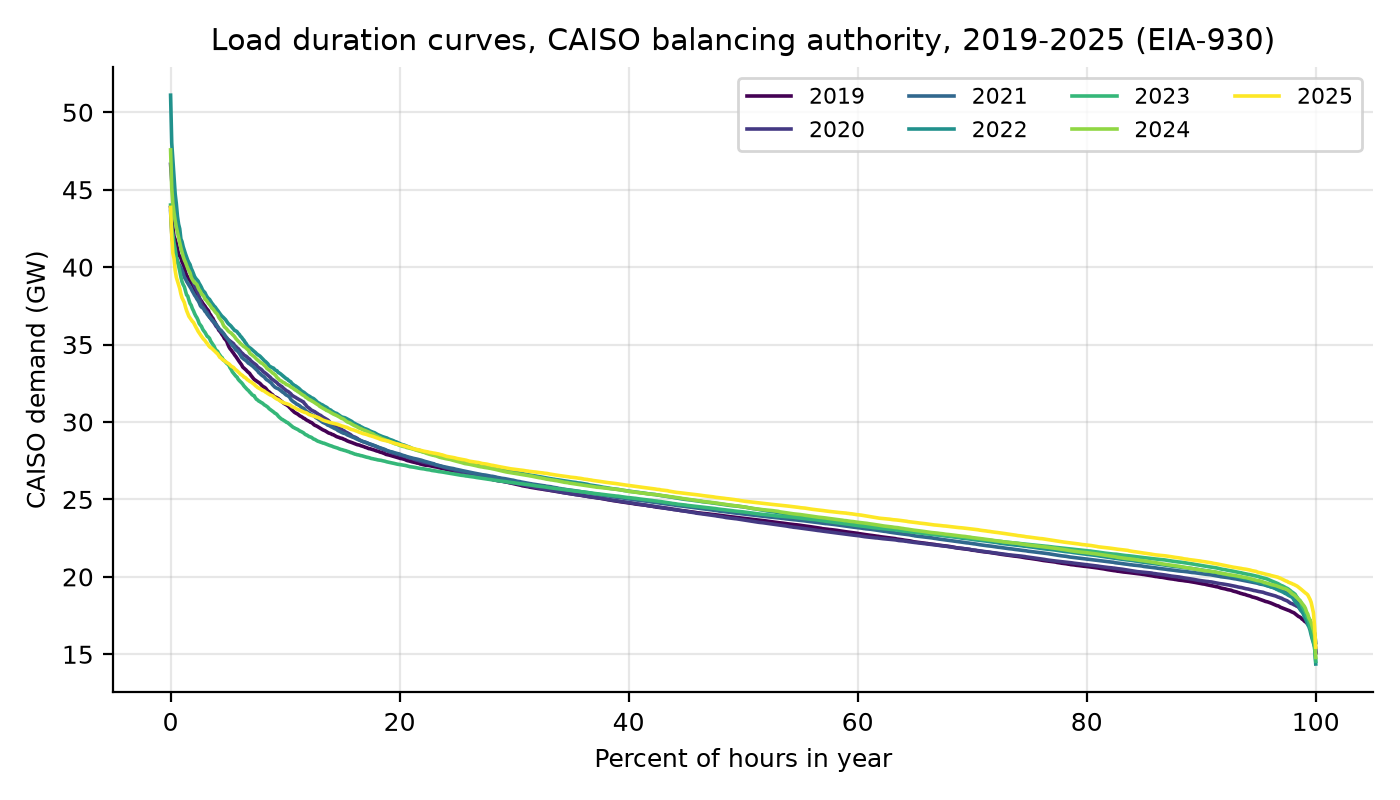

In [4]:
show("fig1_01_load_duration_curves")

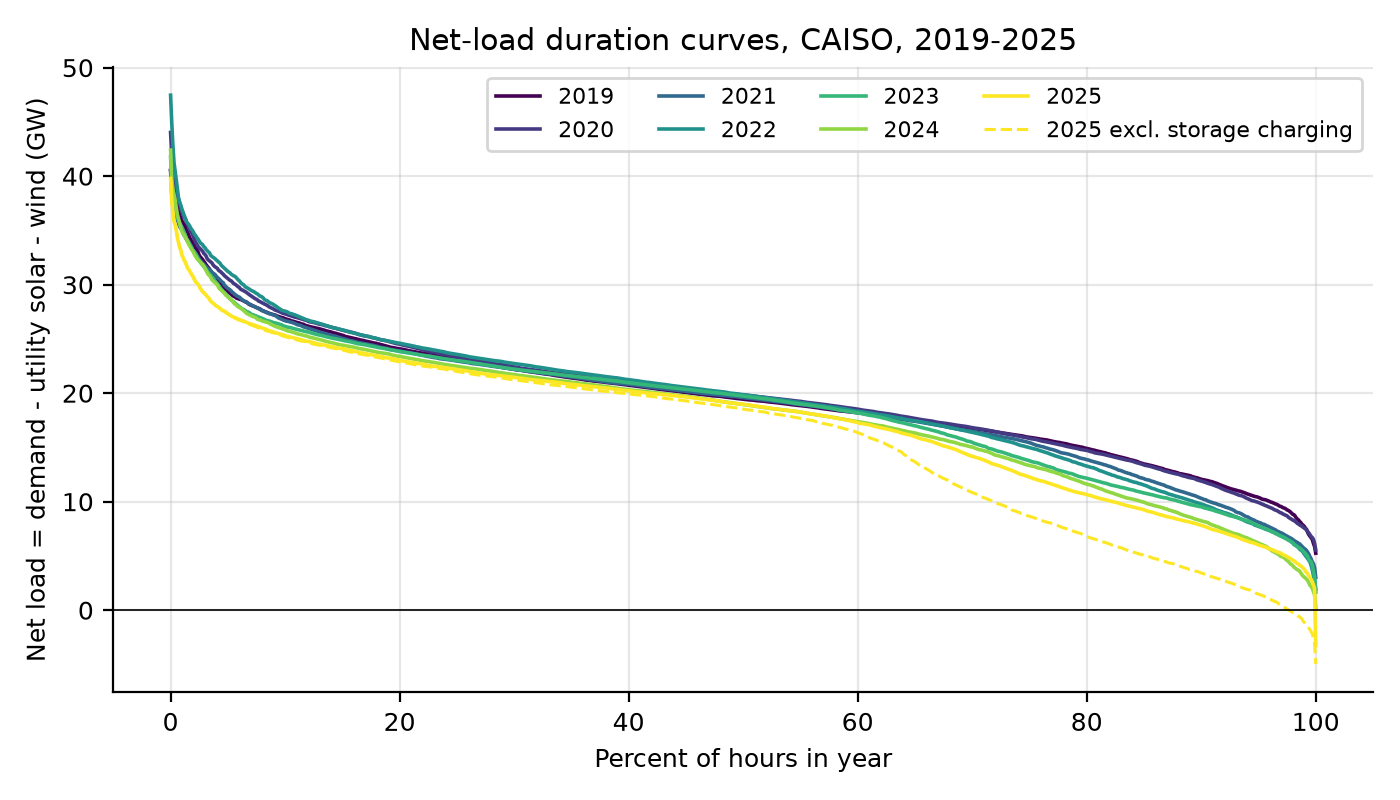

In [5]:
show("fig1_02_net_load_duration_curves")

**Reading.** The load duration curves barely move between years; the net-load duration curves fall steadily at the low end, and by 2025 the lowest-net-load hours are near or below zero, meaning utility solar and wind alone exceed CAISO demand in those hours. This is the midday surplus that later chapters treat as a resource for flexible load.

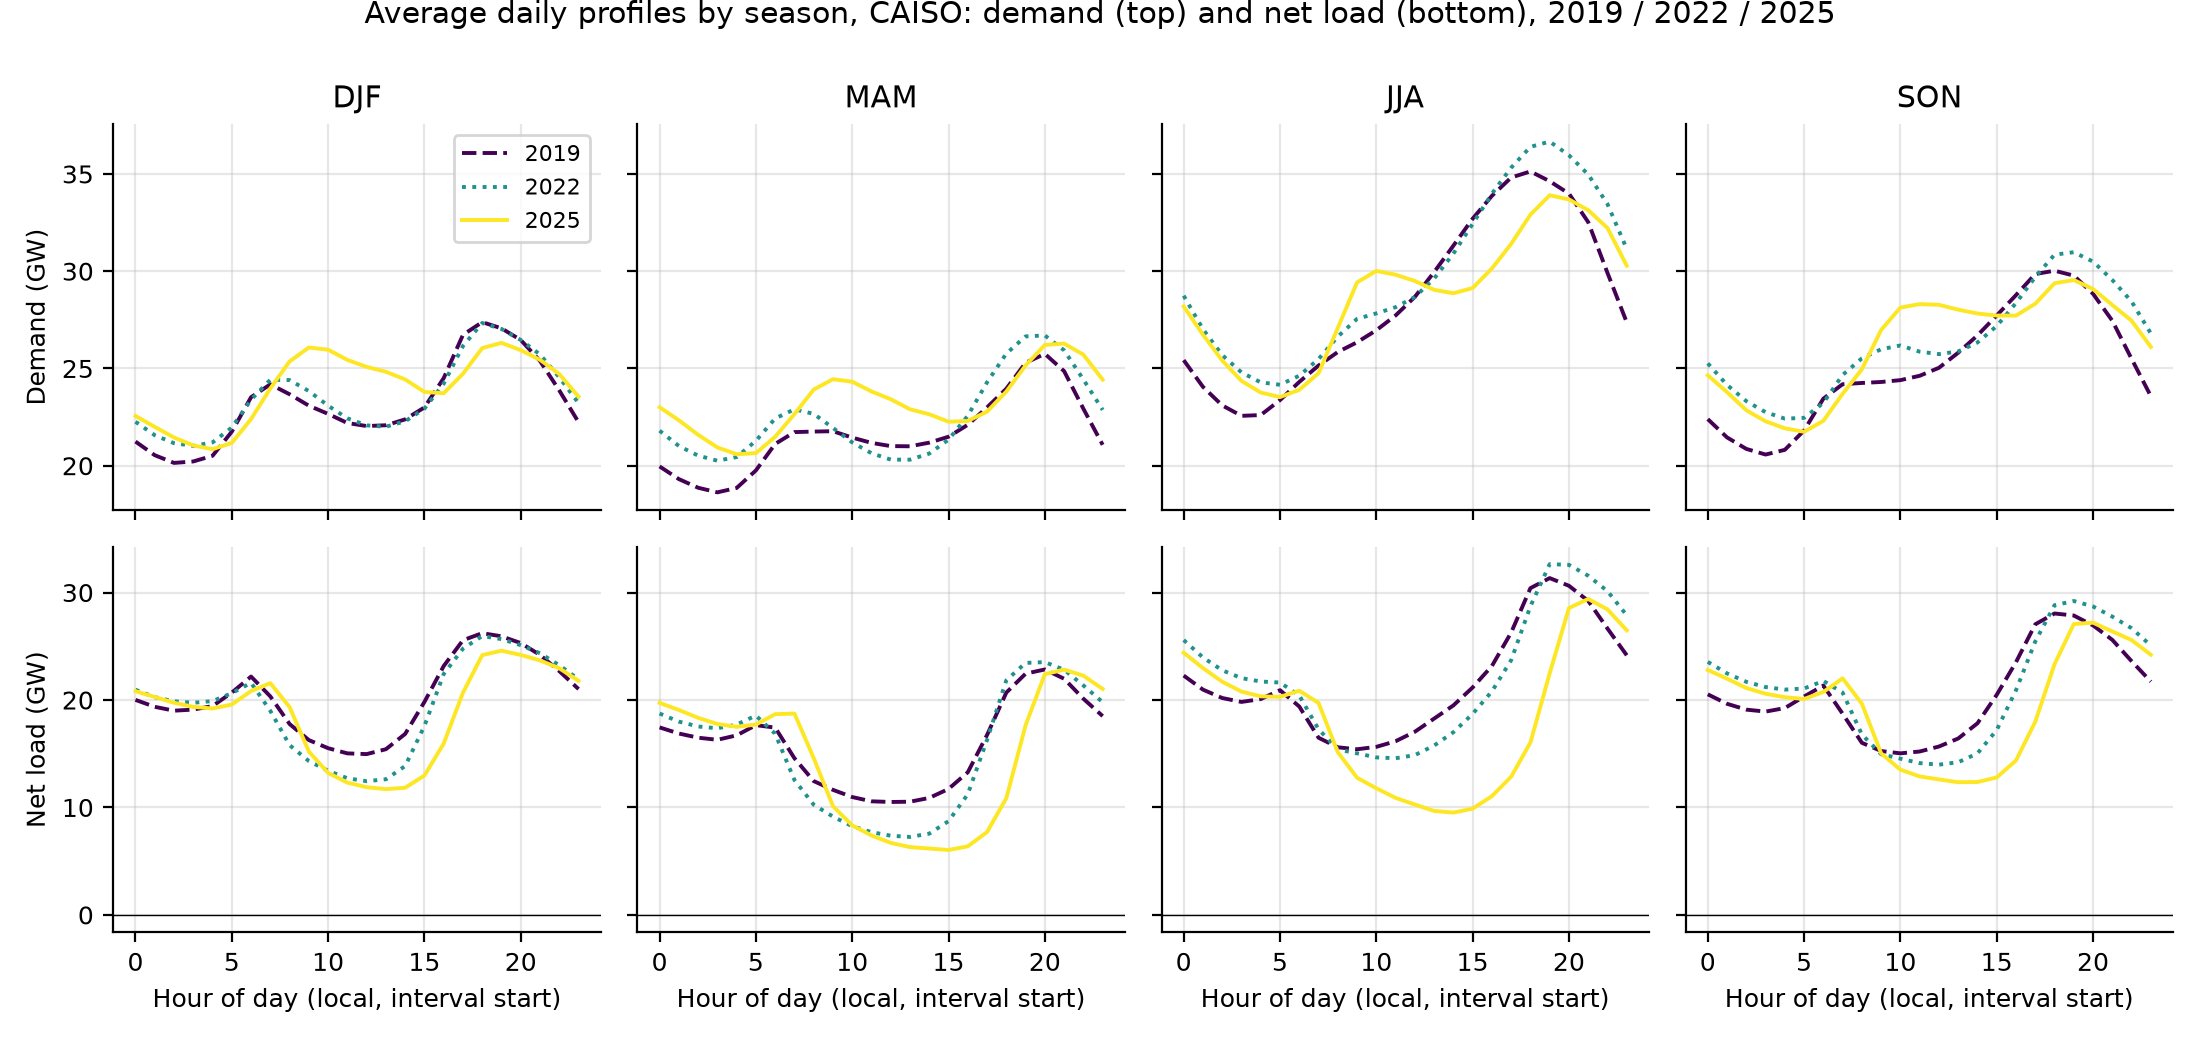

In [6]:
show("fig1_03_seasonal_daily_profiles")

**Reading.** Demand profiles (top) are similar across years; net-load profiles (bottom) show the deepening midday trough and a steeper, later evening ramp. In spring 2025 the average midday net load is about 6 GW against roughly 21 GW at 8 pm.

In [7]:
timing = table("ch1_top100_net_load_timing", index_col=0)
timing[["top100_net_load_min_MW","top100_net_load_max_MW","distinct_days","share_Jul_Sep","share_hours_17_21","median_hour","earliest_hour","latest_hour","mean_solar_MW","mean_imports_MW","mean_gas_MW"]].round(2)

,top100_net_load_min_MW,top100_net_load_max_MW,distinct_days,share_Jul_Sep,share_hours_17_21,median_hour,earliest_hour,latest_hour,mean_solar_MW,mean_imports_MW,mean_gas_MW
year,,,,,,,,,,,
2019,35600.0,40536.0,34,0.90,0.99,18.0,16,21,810.40,8561.93,18471.36
2020,36352.0,44026.0,30,0.92,0.86,18.0,14,22,1241.24,7446.00,22648.94
2021,34671.0,40495.0,42,0.92,1.00,19.0,17,21,606.74,6252.80,21046.35
2022,36583.0,47464.0,27,0.95,0.82,19.0,15,23,1243.06,7401.17,22530.15
2023,34959.0,41764.0,35,0.96,0.93,20.0,17,22,571.16,3571.73,21773.13
2024,34697.0,42403.0,37,0.91,0.79,20.0,18,23,900.78,3109.56,20851.30
2025,32328.0,39787.0,33,0.98,0.78,20.0,18,23,736.47,4550.02,17302.06


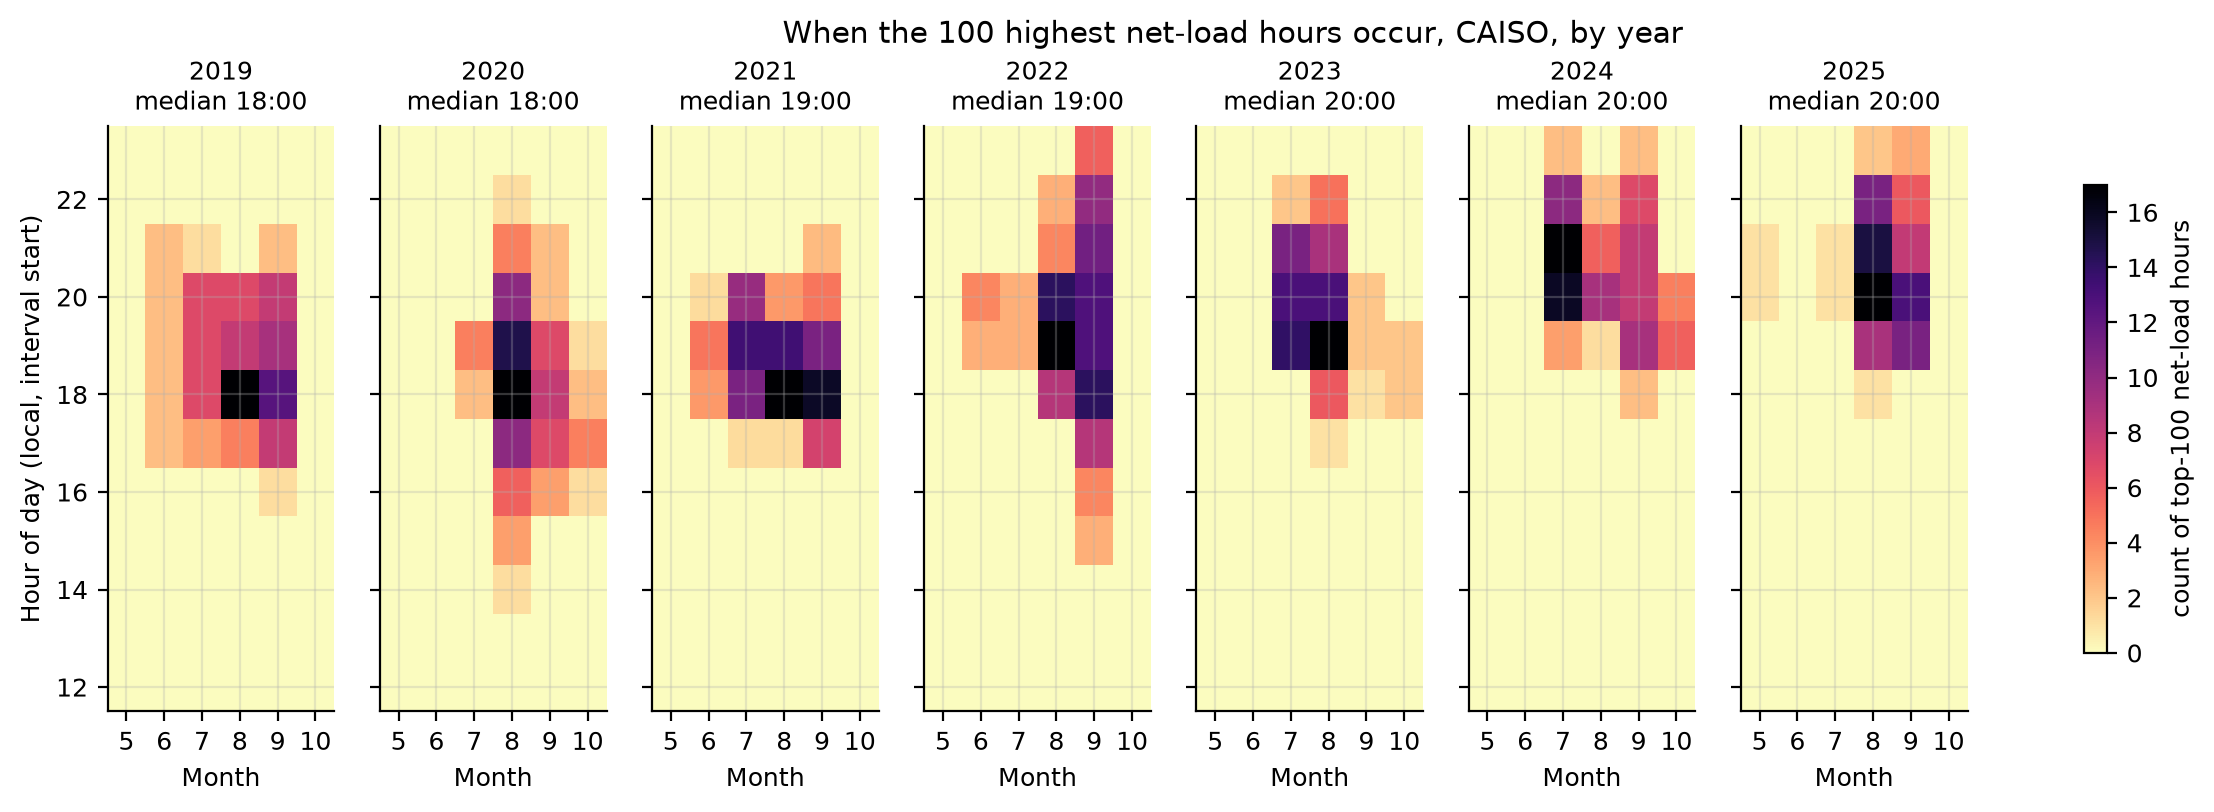

In [8]:
show("fig1_04_top100_net_load_timing")

**Reading.** The 100 highest net-load hours of each year fall almost entirely in July-September and between 5 pm and 9 pm, and their median start time has moved from 6 pm (2019-2020) to 8 pm (2023-2025). Solar contributes under 1.3 GW on average in these hours. A flat data center load therefore adds one-for-one to the hours that set capacity needs; storage and gas, not solar, serve them.

## 2. Day-ahead prices at the default load aggregation points (OASIS PRC_LMP, DAM)

OASIS serves hourly day-ahead prices from July 2023 onward (about 39 months of retention). 2024 and 2025 are complete years; 2023 covers July-December and 2026 covers January to September 22. EIA's daily ICE hub prices (NP15, SP15) extend to 2015 but are daily block averages.

In [9]:
ps = table("ch1_price_stats")
ps[ps.node.str.startswith("DLAP")][["label","year","hours","full_year","mean","median","p5","p95","min","max","hours_negative","hours_le_5","hours_ge_200","share_negative","neg_hours_10_16_share"]].round(3)

,label,year,hours,full_year,mean,median,p5,p95,min,max,hours_negative,hours_le_5,hours_ge_200,share_negative,neg_hours_10_16_share
0,PG&E DLAP,2023,4417,False,58.988,53.843,32.941,91.811,8.666,1133.611,0,0,20,0.000,0.000
1,PG&E DLAP,2024,8784,True,42.993,40.113,8.969,76.151,-33.091,648.767,190,327,67,0.022,0.879
2,PG&E DLAP,2025,8760,True,40.623,42.445,8.657,63.751,-36.810,123.014,218,337,0,0.025,0.940
3,PG&E DLAP,2026,6359,False,31.532,31.894,0.359,60.131,-14.174,217.077,294,480,2,0.046,0.867
4,SCE DLAP,2023,4417,False,57.915,52.527,10.973,107.608,-12.469,1275.330,53,130,57,0.012,0.887
5,SCE DLAP,2024,8784,True,34.020,36.991,-20.000,67.704,-66.600,627.633,1131,1369,52,0.129,0.772
6,SCE DLAP,2025,8760,True,34.411,40.235,-8.336,60.453,-40.479,117.522,877,1109,0,0.100,0.780
7,SCE DLAP,2026,6359,False,28.665,30.340,-8.979,64.832,-17.950,210.480,890,1123,2,0.140,0.719
8,SDG&E DLAP,2023,4417,False,60.020,54.132,11.914,113.021,-11.723,1288.806,40,112,55,0.009,0.925
9,SDG&E DLAP,2024,8784,True,36.212,38.189,-17.333,72.507,-63.086,637.022,989,1227,52,0.113,0.768


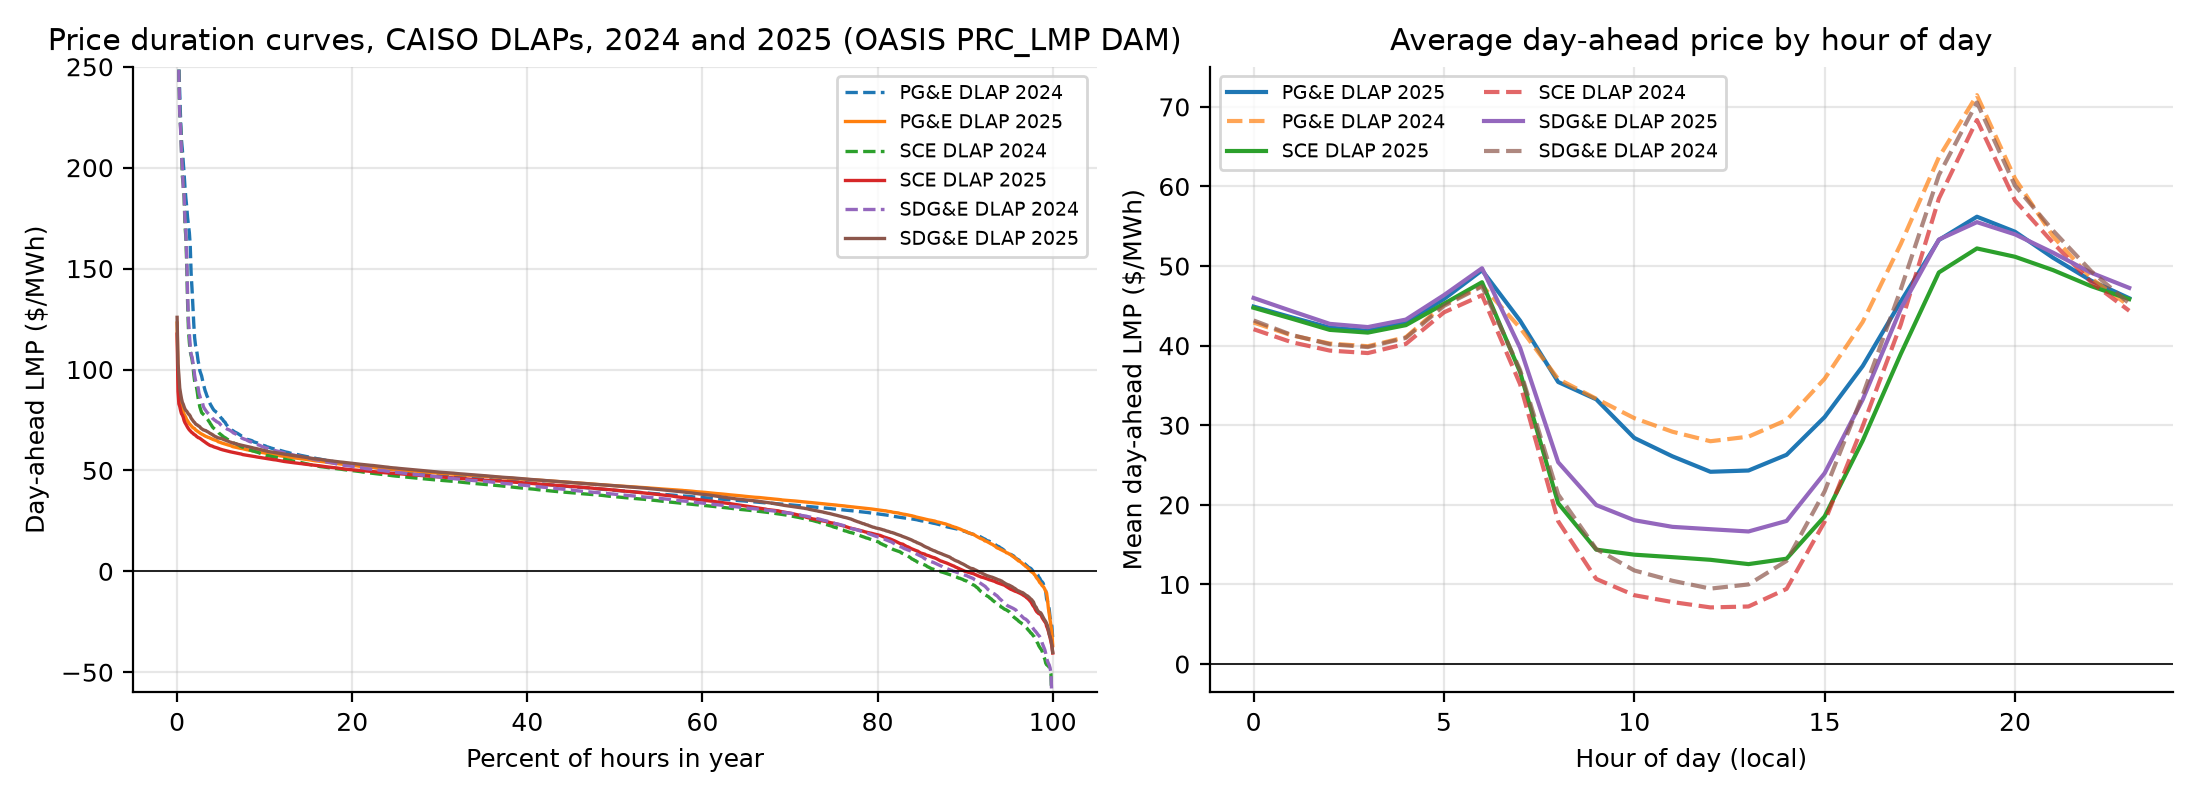

In [10]:
show("fig1_05_price_duration_and_diurnal")

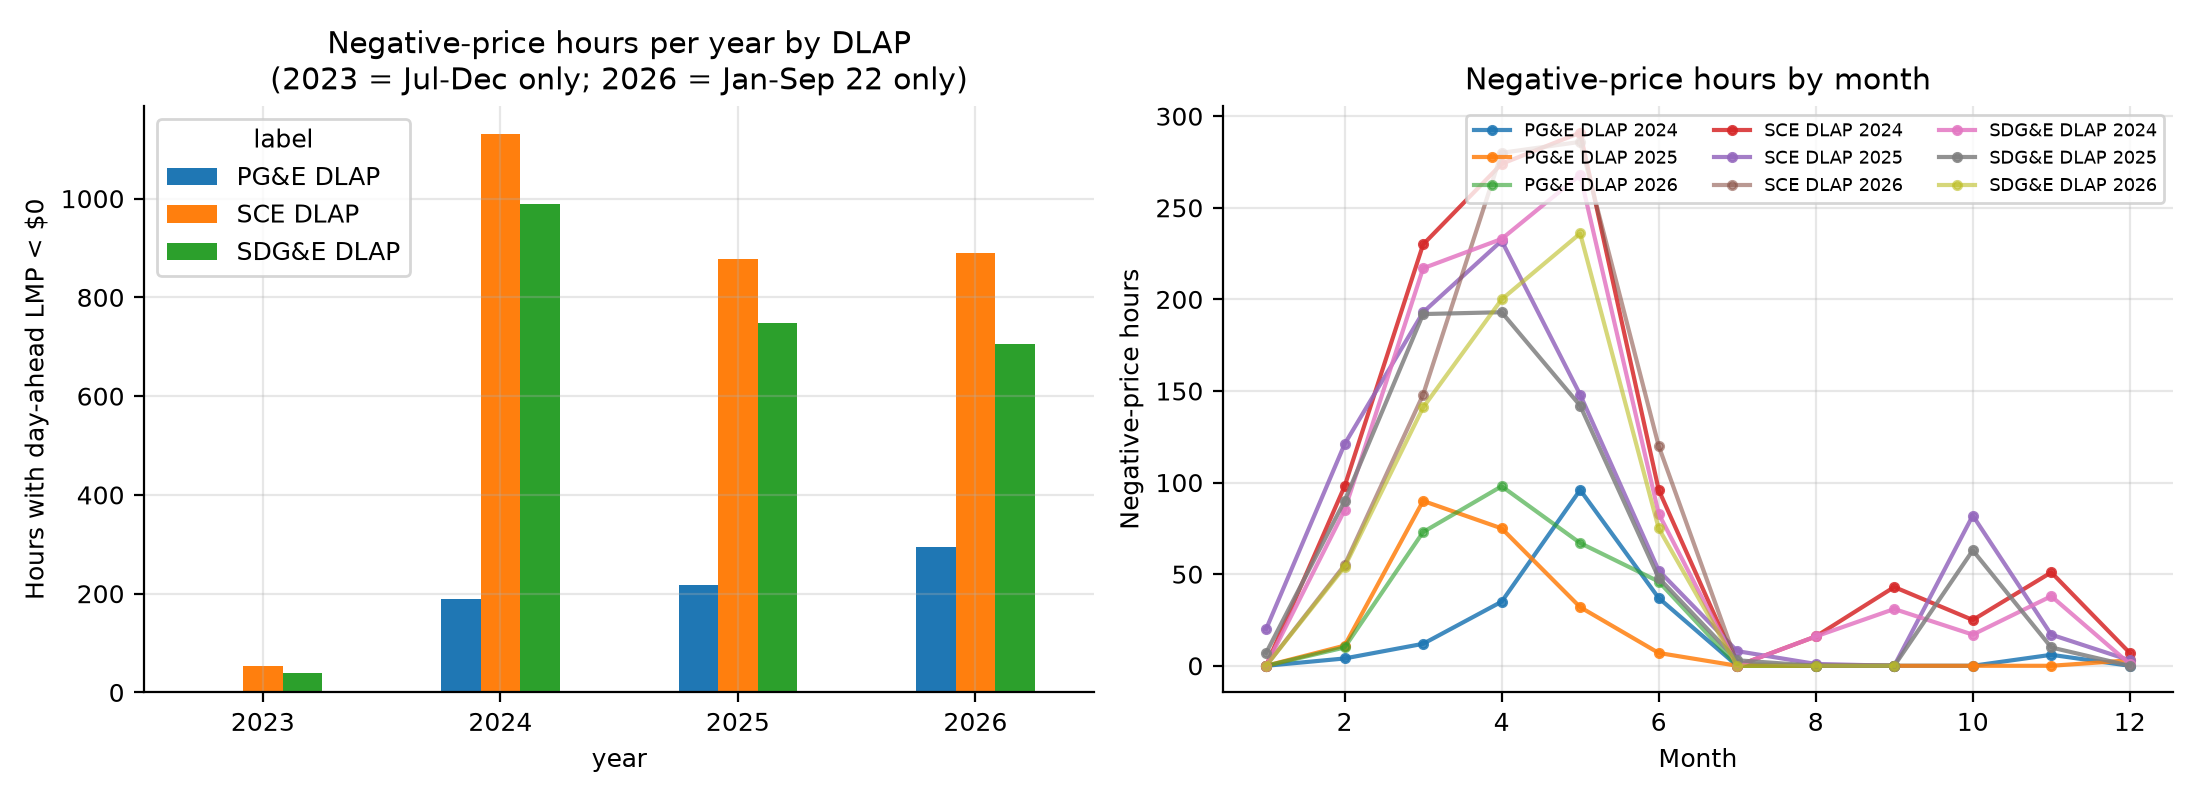

In [11]:
show("fig1_06_negative_price_hours")

In [12]:
nb = table("ch1_negative_price_hours_by_month")
nb[nb.year.isin([2024, 2025, 2026])].pivot(index="month", columns="year", values=["DLAP_PGAE-APND","DLAP_SCE-APND","DLAP_SDGE-APND"])

DLAP_PGAE-APND             DLAP_SCE-APND               DLAP_SDGE-APND              
year            2024  2025  2026          2024   2025   2026           2024   2025   2026
month                                                                                    
1                0.0   0.0   0.0           0.0   20.0    0.0            0.0    7.0    0.0
2                4.0  11.0  10.0          98.0  121.0   55.0           85.0   90.0   54.0
3               12.0  90.0  73.0         230.0  193.0  148.0          217.0  192.0  141.0
4               35.0  75.0  98.0         274.0  232.0  280.0          233.0  193.0  200.0
5               96.0  32.0  67.0         291.0  148.0  286.0          268.0  142.0  236.0
6               37.0   7.0  46.0          96.0   52.0  120.0           83.0   48.0   75.0
7                0.0   0.0   0.0           0.0    8.0    1.0            0.0    3.0    0.0
8                0.0   0.0   0.0          16.0    1.0    0.0           16.0    0.0    0.0
9                0.0   0.0   0.0          43.0    0.0    0.0           31.0    0.0    0.0
10               0.0   0.0   NaN          25.0   82.0    NaN           17.0   63.0    NaN
11               6.0   0.0   NaN          51.0   17.0    NaN           38.0   10.0    NaN
12               0.0   3.0   NaN           7.0    3.0    NaN            1.0    0.0    NaN

In [13]:
ice = table("ch1_ice_daily_hub_prices_negative_days"); ice[ice.hub.str.contains("DA")]

,hub,year,trading_days,days_wavg_negative,days_low_negative,mean_wavg,min_low
0,NP15 EZ Gen DA LMP Peak,2015,145,0,0,36.553862,28.00
1,NP15 EZ Gen DA LMP Peak,2016,126,0,0,33.468333,18.00
2,NP15 EZ Gen DA LMP Peak,2017,93,0,0,42.126064,14.75
3,NP15 EZ Gen DA LMP Peak,2018,44,0,0,79.339545,27.75
4,NP15 EZ Gen DA LMP Peak,2019,38,0,0,59.733947,17.00
5,NP15 EZ Gen DA LMP Peak,2020,38,0,0,58.533421,13.50
6,NP15 EZ Gen DA LMP Peak,2021,60,0,0,76.426167,27.00
7,NP15 EZ Gen DA LMP Peak,2022,68,0,0,107.997353,35.50
8,NP15 EZ Gen DA LMP Peak,2023,98,0,0,73.587653,15.25
9,NP15 EZ Gen DA LMP Peak,2024,82,0,0,47.711707,9.00


**Reading.** Negative day-ahead prices are now routine in Southern California: the SCE aggregation point cleared below zero in 1,131 hours of 2024 and 877 hours of 2025, and 890 hours in the first 265 days of 2026; PG&E's point saw 190-294 hours. Three quarters or more of those hours fall between 10 am and 4 pm, concentrated in February-June. Daily block prices from ICE almost never go negative, which is why the hourly series is needed. This is the California-specific fact that matters for load flexibility: a data center able to shift or add consumption into those hours faces a zero or negative marginal energy price.

## 3. Hourly carbon intensity of CAISO demand

CAISO's Today's Outlook reports 5-minute CO2 by source including imports (metric tons per hour). Intensity here is total CO2 divided by CAISO demand, in g CO2 per kWh, energy-weighted per year. eGRID's CAMX annual output emission rate is the reference annual factor (generation-based, 2023).

In [14]:
cs = table("ch1_carbon_intensity_annual", index_col=0).round(1); eg = json.loads((PROCESSED / "ch1_egrid_camx_2023.json").read_text()); print(eg); cs

{'subregion': 'CAMX', 'year': 2023, 'co2_output_rate_lb_per_MWh': 436.655, 'co2_output_rate_g_per_kWh': 198.06337632235, 'co2e_output_rate_g_per_kWh': 198.76553731111, 'net_generation_TWh': 216.841822331, 'co2_Mt': 47.342486547}


,hours,energy_weighted_g_per_kWh,hourly_mean_g_per_kWh,p5_g_per_kWh,p95_g_per_kWh,min_g_per_kWh,max_g_per_kWh,co2_Mt,imports_co2_share,gas_co2_share
year,,,,,,,,,,
2019,8751,257.0,254.8,110.2,360.6,4.8,435.8,55.9,0.4,0.5
2020,8783,277.4,274.8,131.9,367.9,41.8,424.4,60.4,0.4,0.5
2021,8759,274.5,272.7,125.2,361.4,21.8,395.3,59.7,0.4,0.6
2022,8746,264.7,261.9,108.8,354.8,1.3,417.4,58.1,0.3,0.6
2023,8740,242.3,239.6,86.7,343.9,0.2,433.7,51.1,0.2,0.8
2024,8394,207.3,205.4,45.7,322.6,0.0,384.0,42.7,0.3,0.7
2025,8334,195.3,194.6,33.8,319.9,0.1,362.1,39.1,0.4,0.6


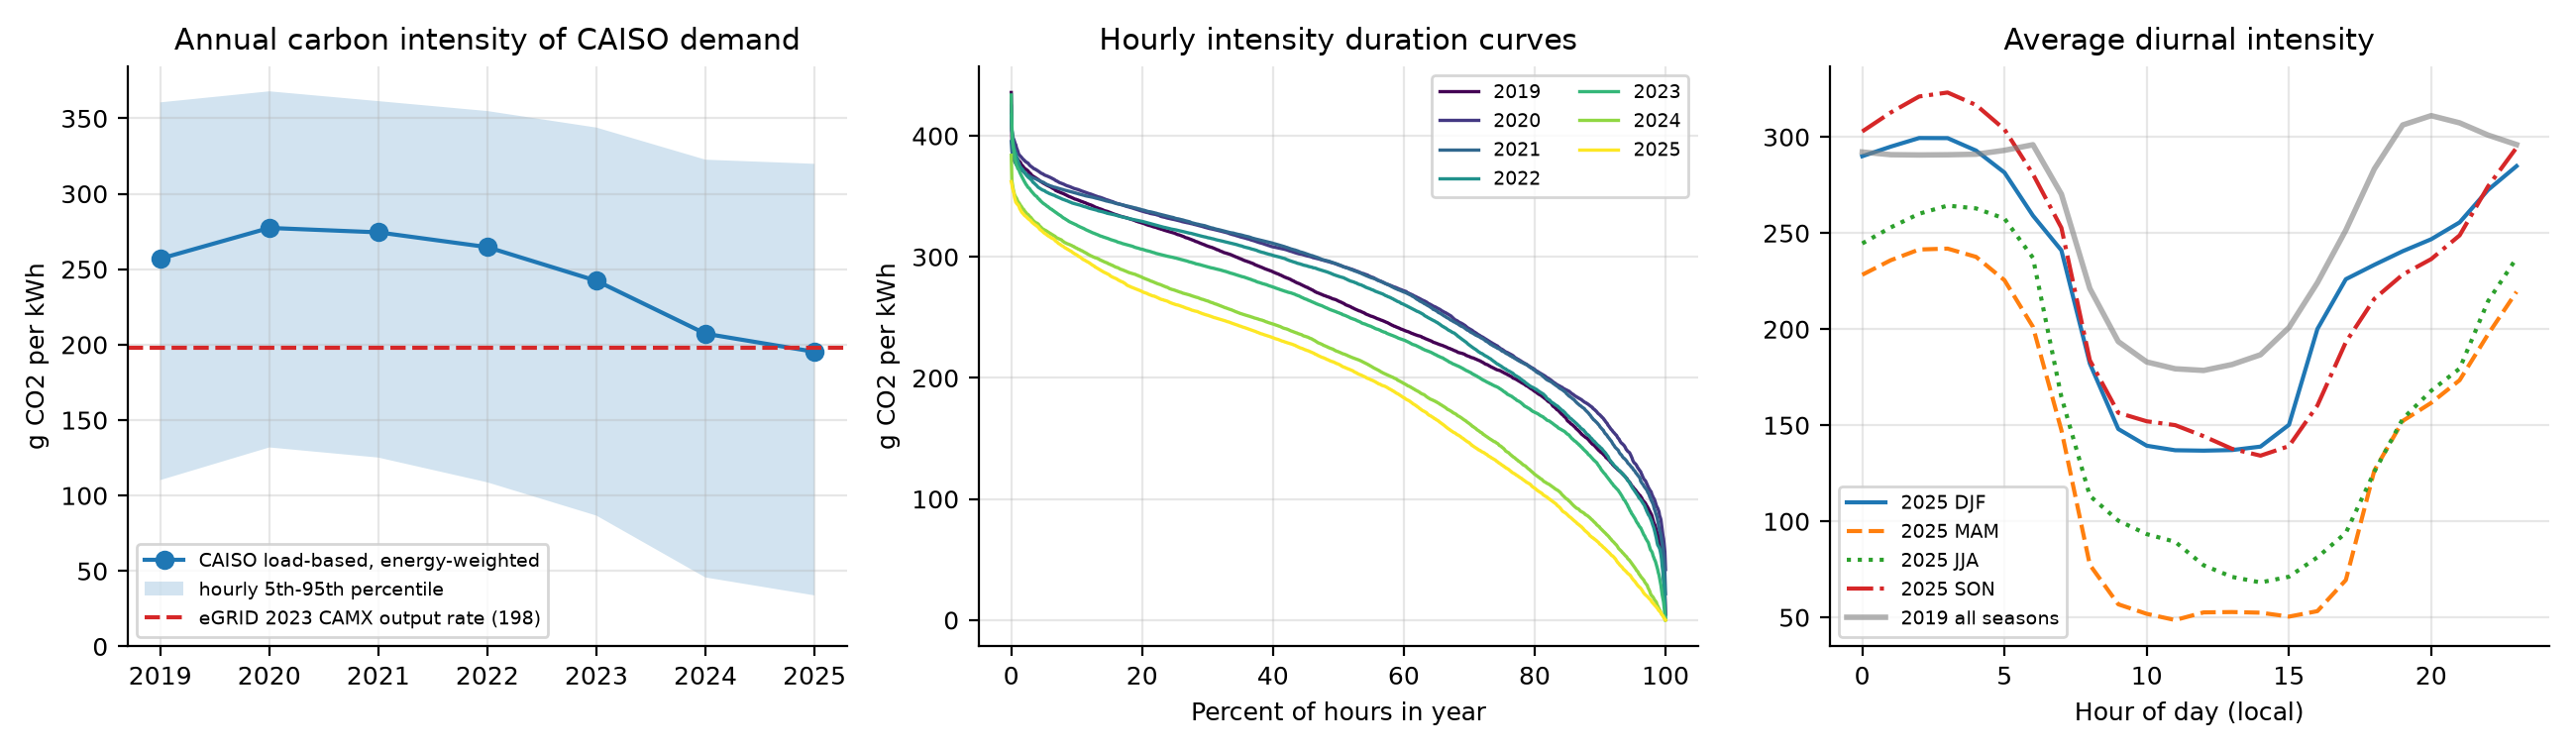

In [15]:
show("fig1_07_carbon_intensity")

In [16]:
bat = table("ch1_battery_summary", index_col=0).round(2); bat

,discharge_TWh,charge_TWh,peak_discharge_MW,peak_charge_MW,hours
year,,,,,
2019,0.05,-0.08,78.17,-85.92,8759
2020,0.06,-0.08,234.00,-202.33,8783
2021,0.83,-0.92,1362.33,-1205.92,8759
2022,2.73,-1.70,2962.50,-2142.83,8759
2023,4.34,-4.45,4780.75,-4295.42,8759
2024,8.20,-9.45,7848.75,-7163.58,8768
2025,12.29,-14.21,10707.33,-9288.83,8759


**Reading.** Load-based intensity fell from about 257 g/kWh in 2019 to about 195 g/kWh in 2025, with spring midday hours near 50 g/kWh and night hours near 240 g/kWh. eGRID's 2023 CAMX output rate (198 g/kWh) is lower than the CAISO load-based 2023 figure (242 g/kWh) because it is generation-based, excludes the default import factor and covers the whole CAMX subregion; the trend is the same. Battery discharge grew from 0.05 TWh in 2019 to 12.3 TWh in 2025 with a 10.7 GW peak, which is what moved the net-peak hours later in the evening.

## 4. Existing data center load in California, four ways

The four estimates are independent in method and source. They are shown against EIA-861 California retail sales for 2024 (Parts A + C + D, to avoid counting delivery-only sales twice). The spread is the finding; no single number is chosen.

In [17]:
rs = table("ch1_ca_retail_sales_eia861"); rs.round(2)

,year,MWh_A_bundled,MWh_B_delivery_only,MWh_C_energy_only,MWh_D_adjustment,retail_sales_TWh
0,2019,183460492.0,66918218.0,66918218.0,0.0,250.38
1,2020,179450656.0,70724016.0,70724016.0,0.0,250.17
2,2021,172633325.0,74616540.0,74616540.0,0.0,247.25
3,2022,166609910.0,85259226.0,85259226.0,0.0,251.87
4,2023,152211367.0,87269085.0,87269085.0,0.0,239.48
5,2024,156099185.0,89617960.0,89617960.0,0.0,245.72


In [18]:
est = table("ch1_dc_load_estimates"); est[["method","low_TWh","central_TWh","high_TWh","low_share_pct","central_share_pct","high_share_pct"]].round(2)

,method,low_TWh,central_TWh,high_TWh,low_share_pct,central_share_pct,high_share_pct
0,EPRI 2024 state table (2023),9.33,9.33,9.33,3.80,3.80,3.80
1,CEC existing peak demand x load factor,7.01,7.71,8.32,2.85,3.14,3.39
2,Count-based bottom-up: Kollar-Grady facilities...,8.44,13.97,18.28,3.43,5.69,7.44
3,Silicon Valley Power cluster only (lower bound),2.43,2.52,2.75,0.99,1.03,1.12


In [19]:
for _, r in est.iterrows(): print(f"- {r.method}\n    basis: {r.basis}\n    sources: {r.source}\n")

- EPRI 2024 state table (2023)
    basis: 9,331,619 MWh = 3.70% of state consumption in 2023 (EPRI Table, p.13 and Appendix p.28)
    sources: epri_powering_intelligence_2024

- CEC existing peak demand x load factor
    basis: ~1,000 MW existing data center peak demand as of Dec 2025 (CEC methodology memo, Apr 2026, pp. 2 and 18); annual load factor 0.80-0.95 from CEC weekday/weekend load-factor profiles (75-100% of annual max)
    sources: cec_dc_methodology_memo_2026; cec_prelim_dc_forecast_2025

- Count-based bottom-up: Kollar-Grady facilities x avg load (Epoch: no CA sites)
    basis: 321 Kollar-Grady facility points inside California (102 within 12 km of Santa Clara); average load per facility 3.0 MW (low), 5.0 MW (SVP-anchored central: 55% of SVP energy over 58 data centers), 6.5 MW (high); Epoch AI Frontier Data Centers Hub lists no California site
    sources: kollar_grady_2025_zenodo; svp_assembly_hearing_2026_01_28; epoch_data_centers

- Silicon Valley Power cluster only (lo

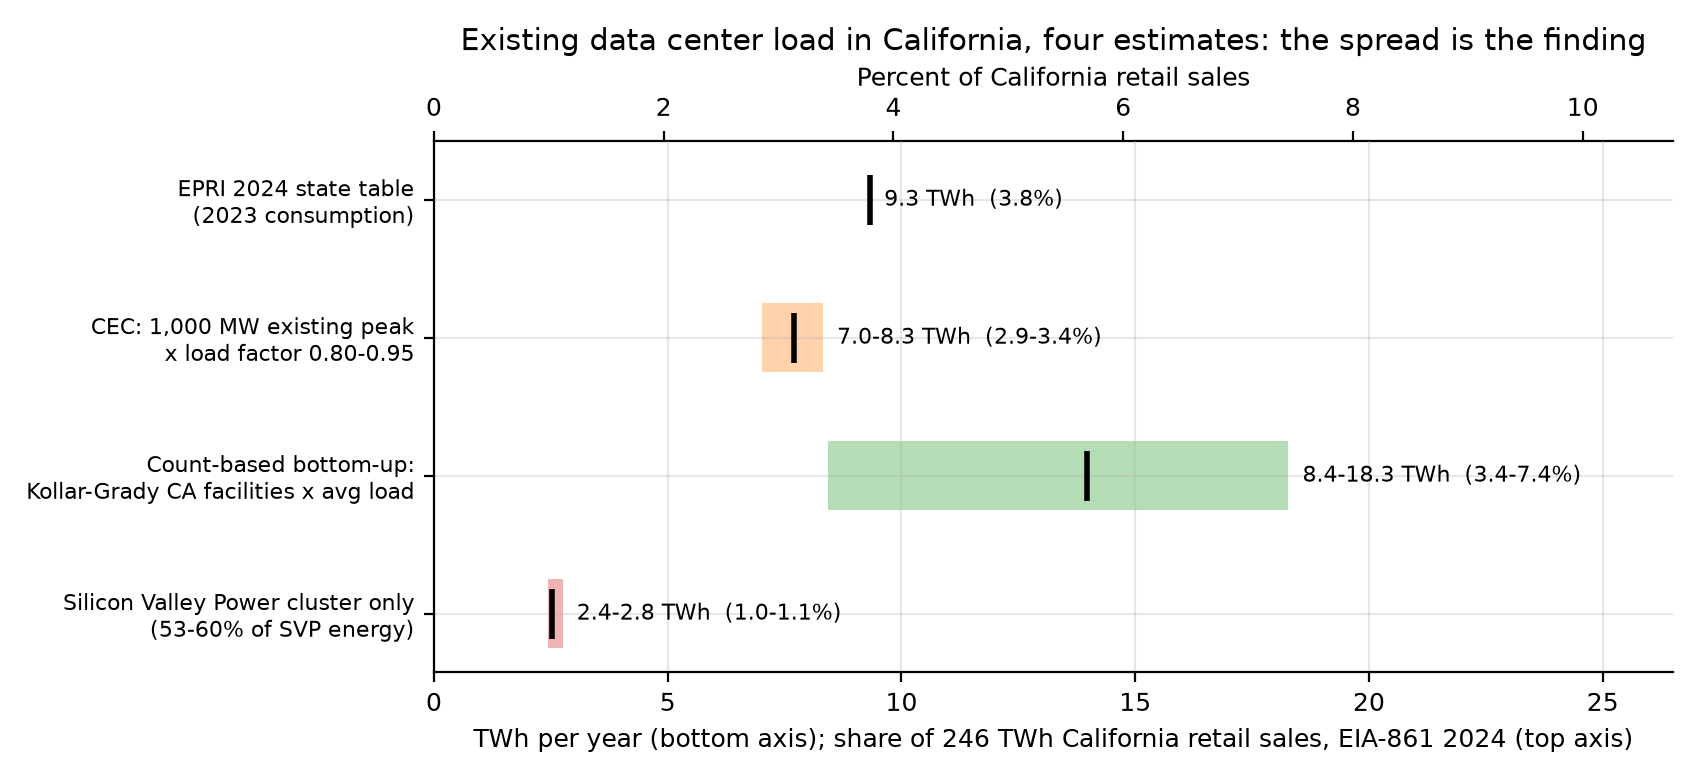

In [20]:
show("fig1_08_existing_dc_load_estimates")

In [21]:
svp = table("ch1_svp_fact_sheets"); bu = json.loads((PROCESSED / "ch1_bottom_up_inputs.json").read_text()); print(bu); svp.round(2)

{'n_california_facilities': 321, 'n_within_12km_of_santa_clara': 102, 'svp_data_centers': 58, 'svp_avg_load_MW_per_facility': 4.96881, 'low_TWh': 8.43588, 'central_TWh': 13.9720949676, 'high_TWh': 18.27774}


,fact_sheet_year,peak_MW,load_factor,electric_accounts,energy_GWh_est
0,2017,586.6,0.72,NaN,3725.50
1,2018,526.2,0.80,55383.0,3692.22
2,2019,587.8,0.72,55116.0,3727.97
3,2020,586.3,0.75,58701.0,3851.99
4,2021,594.8,0.79,57557.0,4131.89
5,2022,693.9,0.74,59803.0,4516.37
6,2023,669.2,0.78,60685.0,4590.10


**Reading.** The two institutional estimates agree: EPRI's 2023 figure (9.3 TWh, 3.7 percent of state consumption) and the CEC's December 2025 baseline of about 1,000 MW of existing data center peak demand (7.0-8.3 TWh at plausible load factors, 2.9-3.4 percent of 2024 retail sales). The count-based bottom-up from 321 Kollar-Grady facility points is wide (8.4-18.3 TWh) because no public source gives per-facility power in California; Epoch's frontier hub lists no California site at all. Silicon Valley Power's cluster alone, 58 data centers drawing 53-60 percent of a 4.6 TWh utility, is 2.4-2.8 TWh, about a third of the CEC statewide baseline and one percent of state retail sales. The defensible statement is: existing data centers use about 3 to 4 percent of California's electricity, possibly more, and one municipal utility in Santa Clara hosts roughly a third of it. Against this roughly 1 GW of existing peak, the CEC's December 2025 energization tiers total 23,277 MW, a 23-fold ratio that is the California analogue of Finland's 27x and the subject of chapter 2.

## 5. Institutional context (documented in `report/sections/02_current_status.tex`)

- **January 2026 single forecast set agreement.** The CEC adopted the CED 2025-2045 forecast set on January 21, 2026 with three data center scenarios, but the joint CEC-CPUC-CAISO agreement (TN 268288, updated April 15, 2026 as TN 269506) directs that CPUC IRP and CAISO bulk-system studies for the 2026-2027 and 2027-2028 transmission planning cycles continue to use the 2024 IEPR planning forecast, and that 2027 resource adequacy requirements use the 2025 IEPR forecast without known loads. Only local transmission studies use the 2025 IEPR local reliability forecast with known loads. Stated rationale: "manages volatility and promotes stability" and gives staff "additional time to collect and review historical data, observe the impacts of known loads, data centers" (TN 269506, pp. 7-8).
- **PG&E pipeline statements.** About 1.5 GW in final engineering or construction (Feb 2025 IEPR workshop, TN 261964); 10 GW pipeline over ten years with 17 projects of about 1.5 GW in final engineering for 2026-2030 (press release, July 31, 2025); "over 12 gigawatts" (Q2 2026 Form 8-K). PG&E has filed a confidentiality request for its project-level data center data every month since August 2025.
- **SCE statements.** Existing data center demand 80 MW with 200 MW near-term and 400 MW mid-term growth (Feb 2025 IEPR workshop, TN 261975); public project database of January 29, 2026 (TN 268459): 115 entries, 8,298 MW requested peak, of which 76 MW in signed agreements, 3,314 MW in applications, 1,773 MW in inquiries and 3,137 MW already canceled; the CEC's summer 2025 tally for SCE was 5,828 MW.
- **CPUC large-load proceedings (verified).** Rulemaking R.26-04-009 on Advanced Electric Rate Design (issued April 10, 2026) will "consider rate design issues for data centers and other large load customers" in coordination with the SB 57 assessment due January 1, 2027. SB 57 (Padilla) was chaptered October 11, 2025 (Stats. 2025, ch. 647). SB 886 (Padilla), the California Technology Innovation and Ratepayer Protection Act, was chaptered September 21, 2026 and requires the CPUC to establish tariffs or update electric rules for participating large customers by January 1, 2028 that prevent stranded costs or cost shifts to other customers. AB 222 was held in Senate Appropriations on August 29, 2025. The CPUC approved interim PG&E Electric Rule 30 for transmission-level service on July 24, 2025.
